# Quantum Computing: First Steps
# Study notes by Gabriel Velazquez

# Introduction

The phenomenon of **quantum entanglement**, famously described by Einstein, Podolsky, and Rosen (EPR) in 1935 as *"spooky action at a distance,"* represents a fundamental departure from classical physics.

Entanglement is not merely a philosophical curiosity; it is the foundational resource for quantum information processing, enabling **quantum teleportation**, **superdense coding**, and **quantum cryptography**.

In this notebook, we explore the preparation and analysis of the **Bell state** $|\Phi^+\rangle$, the maximally entangled state of a two-qubit system. We will approach this topic through three distinct lenses:

* **Mathematical Rigor:** Deriving the state evolution using linear algebra and tensor products in a composite Hilbert space.
* **Ideal Simulation:** Verifying the theoretical derivations using exact statevector simulations.
* **NISQ Hardware Analysis:** Transitioning from ideal theory to the reality of **Noisy Intermediate-Scale Quantum (NISQ)** devices. We will model hardware noise (*depolarization and thermal relaxation*) to understand how decoherence degrades entanglement fidelity on real quantum processors like IBM's `ibmq_lima`.

# Mathematical Background & Quantum Information Foundations

---

## Hilbert Spaces and the Computational Basis

A single qubit is described by a state vector $|\psi\rangle$ residing in a two-dimensional complex Hilbert space $\mathscr{H} \cong \mathbb{C}^2$. We define the computational basis states as:

$$|0\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix}, \quad |1\rangle = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$$

An arbitrary pure state is a superposition $|\psi\rangle = \alpha |0\rangle + \beta |1\rangle$, where $\alpha, \beta \in \mathbb{C}$ and the normalization condition $|\alpha|^2 + |\beta|^2 = 1$ holds.

---

## Tensor Products and Composite Systems

For a multi-qubit system, the state space is constructed via the tensor product of individual Hilbert spaces. For a two-qubit system, the composite Hilbert space is $\mathscr{H}^{\otimes 2} = \mathscr{H} \otimes \mathscr{H} \cong \mathbb{C}^4$. The computational basis for this space is formed by the Kronecker product of the single-qubit basis states:

$$|00\rangle = |0\rangle \otimes |0\rangle = \begin{pmatrix} 1 \\ 0 \\ 0 \\ 0 \end{pmatrix}, \quad |01\rangle = \begin{pmatrix} 0 \\ 1 \\ 0 \\ 0 \end{pmatrix}, \quad |10\rangle = \begin{pmatrix} 0 \\ 0 \\ 1 \\ 0 \end{pmatrix}, \quad |11\rangle = \begin{pmatrix} 0 \\ 0 \\ 0 \\ 1 \end{pmatrix}$$

---

A state is entangled if it cannot be factored into a tensor product of individual qubit states, i.e., $|\psi\rangle \neq |\phi_A\rangle \otimes |\phi_B\rangle$. Entanglement implies that the measurement outcome of one qubit is perfectly correlated with the other, regardless of the spatial separation between them.

# Quantum Gates and Unitary Evolution

Quantum logic gates are represented by unitary operators $U$ ($U^\dagger U = I$) acting on the Hilbert space.

---

## The Hadamard Gate ($H$)

The Hadamard gate creates a superposition from a basis state. Its matrix representation is:

$$H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

Applying $H$ to $|0\rangle$ yields the state $|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$. Geometrically, $H$ corresponds to a 180° rotation around the axis $\frac{\hat{x}+\hat{z}}{\sqrt{2}}$ on the Bloch sphere.

---

## The Controlled-NOT Gate ($CX$)

The $CX$ gate is a two-qubit entangling gate. It applies the Pauli-$X$ (NOT) gate to the target qubit if and only if the control qubit is in the state $|1\rangle$. We can express $CX$ elegantly using projection operators:

$$CX = |0\rangle\langle 0| \otimes I + |1\rangle\langle 1| \otimes X$$

Substituting the matrix representations:

$$CX = \begin{pmatrix} 1 & 0 \\ 0 & 0 \end{pmatrix} \otimes \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} + \begin{pmatrix} 0 & 0 \\ 0 & 1 \end{pmatrix} \otimes \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{pmatrix}$$

---

# Analytical Derivation of the Bell State

We now derive the preparation of the Bell state $|\Phi^+\rangle$ analytically. The circuit consists of applying $H$ to the first qubit, followed by a $CX$ gate with the first qubit as control and the second as target.

---

### Step 1: Initial State

$$|\psi_0\rangle = |0\rangle \otimes |0\rangle = |00\rangle$$

---

### Step 2: Application of $H \otimes I$

The operator acting on the composite system is $H \otimes I$:

$$H \otimes I = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix} \otimes \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 0 & 1 & 0 \\ 0 & 1 & 0 & 1 \\ 1 & 0 & -1 & 0 \\ 0 & 1 & 0 & -1 \end{pmatrix}$$

Applying this to $|\psi_0\rangle$:

$$|\psi_1\rangle = (H \otimes I)|00\rangle = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 \\ 0 \\ 1 \\ 0 \end{pmatrix} = \frac{1}{\sqrt{2}}(|00\rangle + |10\rangle) = |+\rangle \otimes |0\rangle$$

> **Note:** The state is still separable at this stage.

---

### Step 3: Application of $CX$

$$|\psi_2\rangle = CX|\psi_1\rangle = \frac{1}{\sqrt{2}} (CX|00\rangle + CX|10\rangle)$$

Since $CX|00\rangle = |00\rangle$ and $CX|10\rangle = |11\rangle$, we obtain:

$$|\psi_2\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle) \equiv |\Phi^+\rangle$$

This state is maximally entangled. A measurement on the first qubit collapsing it to $|0\rangle$ instantaneously forces the second qubit into $|0\rangle$, and similarly for $|1\rangle$.

# Getting things Ready

In [1]:
!pip install qiskit qiskit-aer pylatexenc

# Implementation and Ideal Simulation

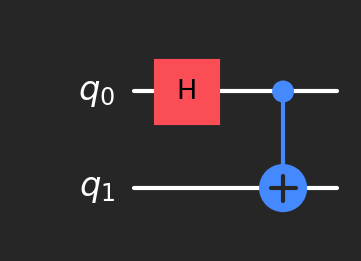

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_city
from qiskit.quantum_info import Statevector, DensityMatrix, state_fidelity

# Dark Mode
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", font_scale=1.2)
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.facecolor': '#121212', # Axis Color
    'figure.facecolor': '#121212' # Figure Color
})

def create_bell_circuit() -> QuantumCircuit:
    """
    Constructs a 2-qubit quantum circuit to prepare the Bell state |Φ⁺⟩.

    Returns:
        QuantumCircuit: The prepared quantum circuit.
    """
    qr = QuantumRegister(2, name='q')
    cr = ClassicalRegister(2, name='c')
    qc = QuantumCircuit(qr, cr)

    # Step 1: Hadamard on qubit 0
    qc.h(qr[0])
    # Step 2: CNOT with control=0, target=1
    qc.cx(qr[0], qr[1])

    # Measurement
    qc.measure(qr, cr)
    return qc

# Initialize the circuit
bell_circuit = create_bell_circuit()

# To visualize without measurements, we create a copy and remove them
bell_circuit_no_meas = bell_circuit.copy()
bell_circuit_no_meas.remove_final_measurements()

# 'iqp-dark' style
display(bell_circuit_no_meas.draw(output='mpl', style='iqp-dark'))

# Statevector Evolution

We use the statevector_simulator to extract the exact complex probability amplitudes, verifying our analytical derivation.


# This code may be reuse for visualization of vector states in a asthetical way

In [3]:
from qiskit.visualization import array_to_latex

# Simulate the exact statevector
backend_sv = Aer.get_backend('statevector_simulator')
job = backend_sv.run(bell_circuit_no_meas)
statevector = job.result().get_statevector()

print("Final Statevector |ψ₂⟩:")
# Display the statevector in LaTeX for a professional look
display(array_to_latex(statevector, prefix="|\\Phi^+\\rangle = "))

# Visualize the state using a city plot with dark theme compatible colors
# We use 'plot_state_city' and pass the figure to modify its background if necessary
fig = plot_state_city(statevector,
                      title=r"City Plot of the Bell State $|\Phi^+\rangle$",
                      color=['#00bfff', '#ff1493'],
                      figsize=(15, 6))

# Ensuring the figure background matches our dark theme
fig.patch.set_facecolor('#121212')
for ax in fig.axes:
    ax.set_facecolor('#121212')

plt.show()

Final Statevector |ψ₂⟩:


<IPython.core.display.Latex object>

## Bloch Sphere Representation

While the Bloch sphere is strictly defined for single qubits, Qiskit provides a visualization of the reduced density matrices (or the marginal states) of the multi-qubit system.

For a maximally entangled state, the reduced density matrix of either qubit is the maximally mixed state:

$$\rho = \frac{I}{2}$$

This corresponds to the origin of the Bloch sphere.

This topic will be seen deeper later  ( I hope)

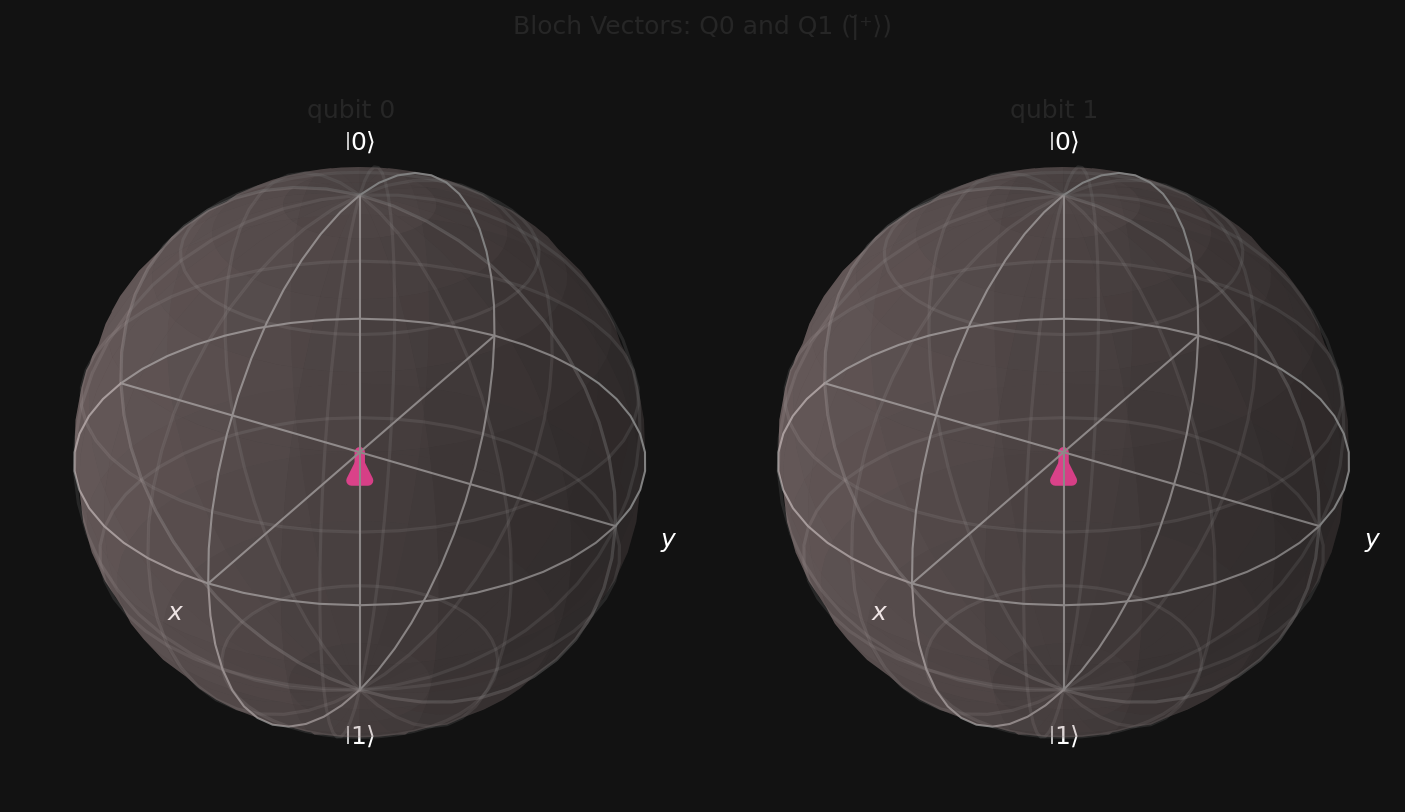

In [4]:
from qiskit.visualization import plot_bloch_multivector

# Optimized style for dark mode in Qiskit
bloch_style = {
    'background': '#121212',
    'foreground': 'white',
    'active_point_color': '#ff007f'
}

# Generate the visualization with the applied style
fig = plot_bloch_multivector(statevector,
                             title="Bloch Vectors: Q0 and Q1 (|̆⁺⟩)",
                             font_size=12)

# Force background and label colors for dark notebook
fig.patch.set_facecolor('#121212')
for ax in fig.axes:
    ax.set_facecolor('#121212')
    for text in ax.texts:
        text.set_color('white')

display(fig)

# Quantum Measurement Postulate

According to the postulates of quantum mechanics, measurement is described by a set of measurement operators $\{M_m\}$ satisfying the completeness equation $\sum_m M_m^\dagger M_m = I$. For projective measurements in the computational basis, the projectors are:

$$P_{00} = |00\rangle\langle 00|, \quad P_{01} = |01\rangle\langle 01|, \quad P_{10} = |10\rangle\langle 10|, \quad P_{11} = |11\rangle\langle 11|$$

The probability of obtaining outcome $m$ is given by the Born rule:

$$p(m) = \langle\psi|P_m|\psi\rangle = |\langle m|\psi\rangle|^2$$

For $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$:

$$p(00) = \left|\frac{1}{\sqrt{2}}\right|^2 = 0.5, \quad p(11) = 0.5, \quad p(01) = p(10) = 0$$

## Ideal Sampling (QASM Simulator)

In practice, quantum computers are stochastic. We simulate the sampling process using the `qasm_simulator`.

Ideal Measurement Counts (Shots: 8192):
{'00': 4072, '11': 4120}


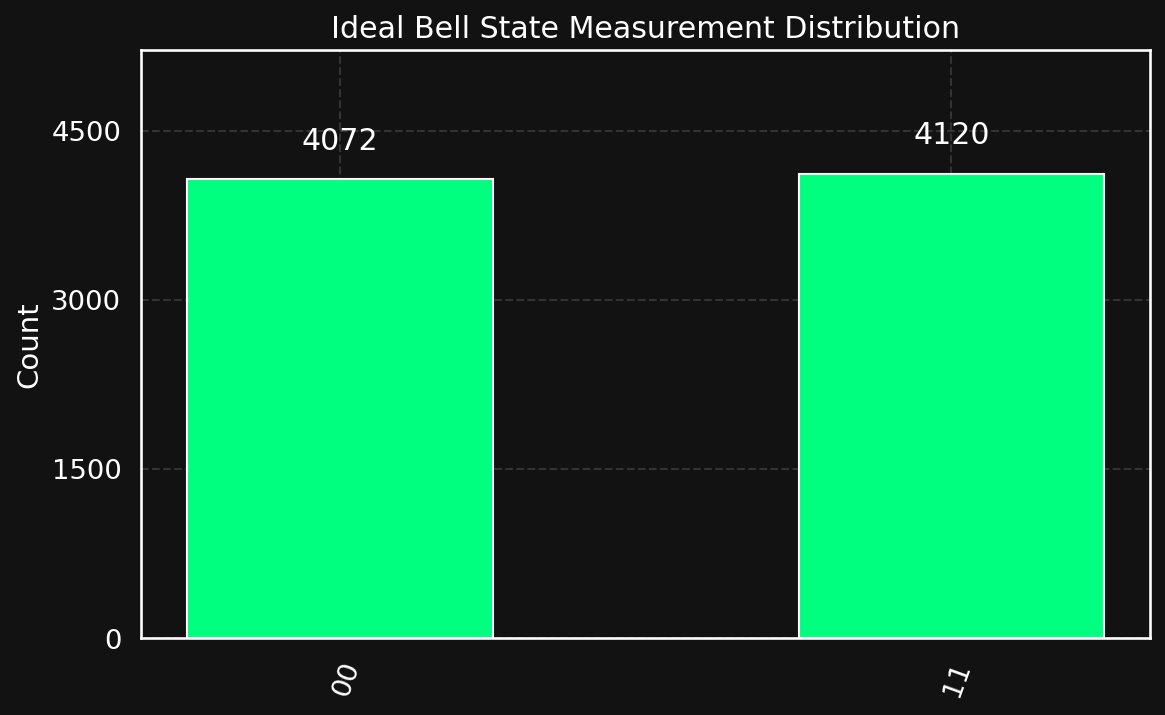

In [5]:
backend_qasm = Aer.get_backend('qasm_simulator')
shots = 8192

# Run the circuit with measurements
result_ideal = backend_qasm.run(bell_circuit, shots=shots).result()
counts_ideal = result_ideal.get_counts()

print(f"Ideal Measurement Counts (Shots: {shots}):")
print(counts_ideal)

# Create the plot and fix styling for dark mode readability
fig, ax = plt.subplots(figsize=(8, 5))
plot_histogram(counts_ideal, ax=ax, color='#00ff7f', title='Ideal Bell State Measurement Distribution')

# Adjust text colors manually for high visibility in dark mode
ax.title.set_color('white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

# Fix the color of the count labels above the bars
for text in ax.texts:
    text.set_color('white')

# Increase Y-axis limit to prevent overlap with the top frame
current_ylim = ax.get_ylim()
ax.set_ylim(0, current_ylim[1] * 1.15)

# Improve grid visibility
ax.grid(color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# NISQ Hardware and Noise Modeling

The theoretical derivation assumes a perfectly isolated quantum system undergoing unitary evolution. However, real quantum hardware operates in the **NISQ (Noisy Intermediate-Scale Quantum)** regime.

Qubits interact with their environment, leading to decoherence and gate errors.

## Constructing a Hardware Noise Model

Since accessing real IBM Quantum hardware requires an API token and queue times, we will construct a high-fidelity noise model using Qiskit Aer that emulates the typical error rates of the `ibmq_lima` backend.

This allows us to rigorously analyze the degradation of entanglement fidelity.

In [6]:
from qiskit_aer.noise import NoiseModel, depolarizing_error, thermal_relaxation_error

def create_ibmq_lima_noise_model() -> NoiseModel:
    """
    Constructs a noise model approximating the ibmq_lima backend.

    Returns:
        NoiseModel: The configured Qiskit Aer noise model.
    """
    noise_model = NoiseModel()

    # Typical error rates for superconducting transmon qubits
    p1q = 0.001   # 1-qubit gate depolarizing error rate
    p2q = 0.020   # 2-qubit gate depolarizing error rate

    # Thermal relaxation times (in seconds)
    t1 = 50e-6    # T1 relaxation time
    t2 = 70e-6    # T2 dephasing time

    # Gate execution times (in seconds)
    gate_time_1q = 50e-9
    gate_time_2q = 300e-9

    # 1. Basic Errors
    error_1q_depol = depolarizing_error(p1q, 1)
    error_2q_depol = depolarizing_error(p2q, 2)

    # 2. Thermal Relaxation Errors
    error_1q_thermal = thermal_relaxation_error(t1, t2, gate_time_1q)
    error_2q_thermal = thermal_relaxation_error(t1, t2, gate_time_2q)

    # Combine errors using .compose() instead of .expand() to keep qubit count correct
    error_1q = error_1q_thermal.compose(error_1q_depol)
    error_2q = error_2q_thermal.compose(error_2q_depol)

    # Add to noise model
    noise_model.add_all_qubit_quantum_error(error_1q, ['u1', 'u2', 'u3', 'id'])
    noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

    return noise_model

noise_model = create_ibmq_lima_noise_model()
print("Noise model constructed successfully using .compose()")

Noise model constructed successfully using .compose()


# Noisy Simulation and Error Analysis

We execute the same Bell state circuit using the noisy simulator and compare the results.

Noisy Measurement Counts:
{'01': 40, '11': 4029, '10': 74, '00': 4049}


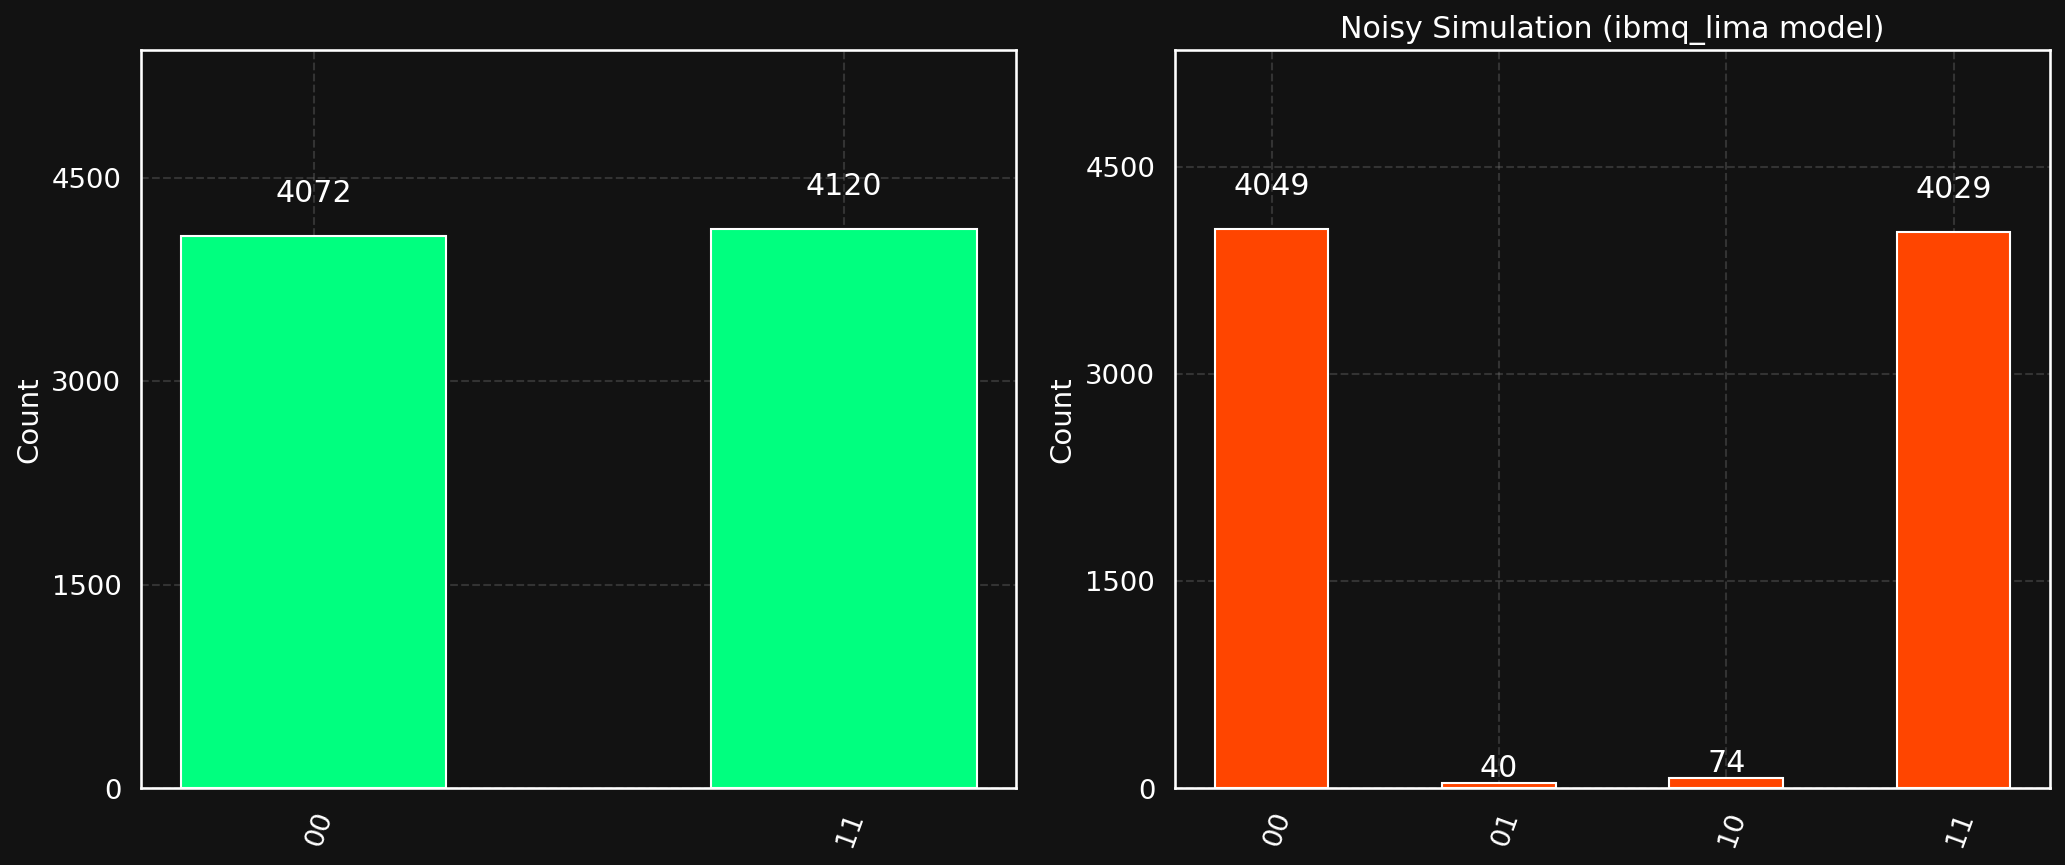

In [7]:
backend_noisy = Aer.get_backend('qasm_simulator')
result_noisy = backend_noisy.run(bell_circuit, shots=shots, noise_model=noise_model).result()
counts_noisy = result_noisy.get_counts()

print("Noisy Measurement Counts:")
print(counts_noisy)

# Plotting comparison with fixed dark mode styling
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ideal Histogram
plot_histogram(counts_ideal, ax=axes[0], color='#00ff7f', title='Ideal Simulation')
# Noisy Histogram
plot_histogram(counts_noisy, ax=axes[1], color='#ff4500', title='Noisy Simulation (ibmq_lima model)')

for ax in axes:
    # Set text colors to white
    ax.title.set_color('white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')

    # Fix count labels color
    for text in ax.texts:
        text.set_color('white')

    # Add headroom to avoid overlap with frame
    curr_ylim = ax.get_ylim()
    ax.set_ylim(0, curr_ylim[1] * 1.2)

    # Grid styling
    ax.grid(color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Fidelity and Quantum State Tomography

To quantify the impact of noise, we calculate the **State Fidelity**, which measures the "closeness" of the noisy density matrix $\rho_{\text{noisy}}$ to the ideal pure state $|\psi_{\text{ideal}}\rangle$.

The fidelity is defined as:

$$F(\rho, |\psi\rangle) = \langle\psi|\rho|\psi\rangle$$

In [8]:
# Get the ideal statevector for comparison
ideal_state = Statevector.from_instruction(bell_circuit_no_meas)

# Prepare the circuit to save the density matrix
qc_density = bell_circuit_no_meas.copy()
qc_density.save_density_matrix()

# Simulation with aer_simulator and the noise model
backend = Aer.get_backend('aer_simulator')
result = backend.run(qc_density, noise_model=noise_model).result()

# Access the density matrix
noisy_density = result.data()['density_matrix']

# Calculate Fidelity
fidelity = state_fidelity(ideal_state, noisy_density)

print(f"Ideal State: |̆⁺⟩")
print(f"Noisy Matrix Trace: {np.trace(noisy_density).real:.4f}")
print(f"State Fidelity (F): {fidelity:.4f}")

Ideal State: |̆⁺⟩
Noisy Matrix Trace: 1.0000
State Fidelity (F): 0.9814


## Visualizing the Density Matrix

We can visualize the real and imaginary parts of the noisy density matrix to observe how off-diagonal elements (*coherences*) decay due to dephasing ($T_2$).

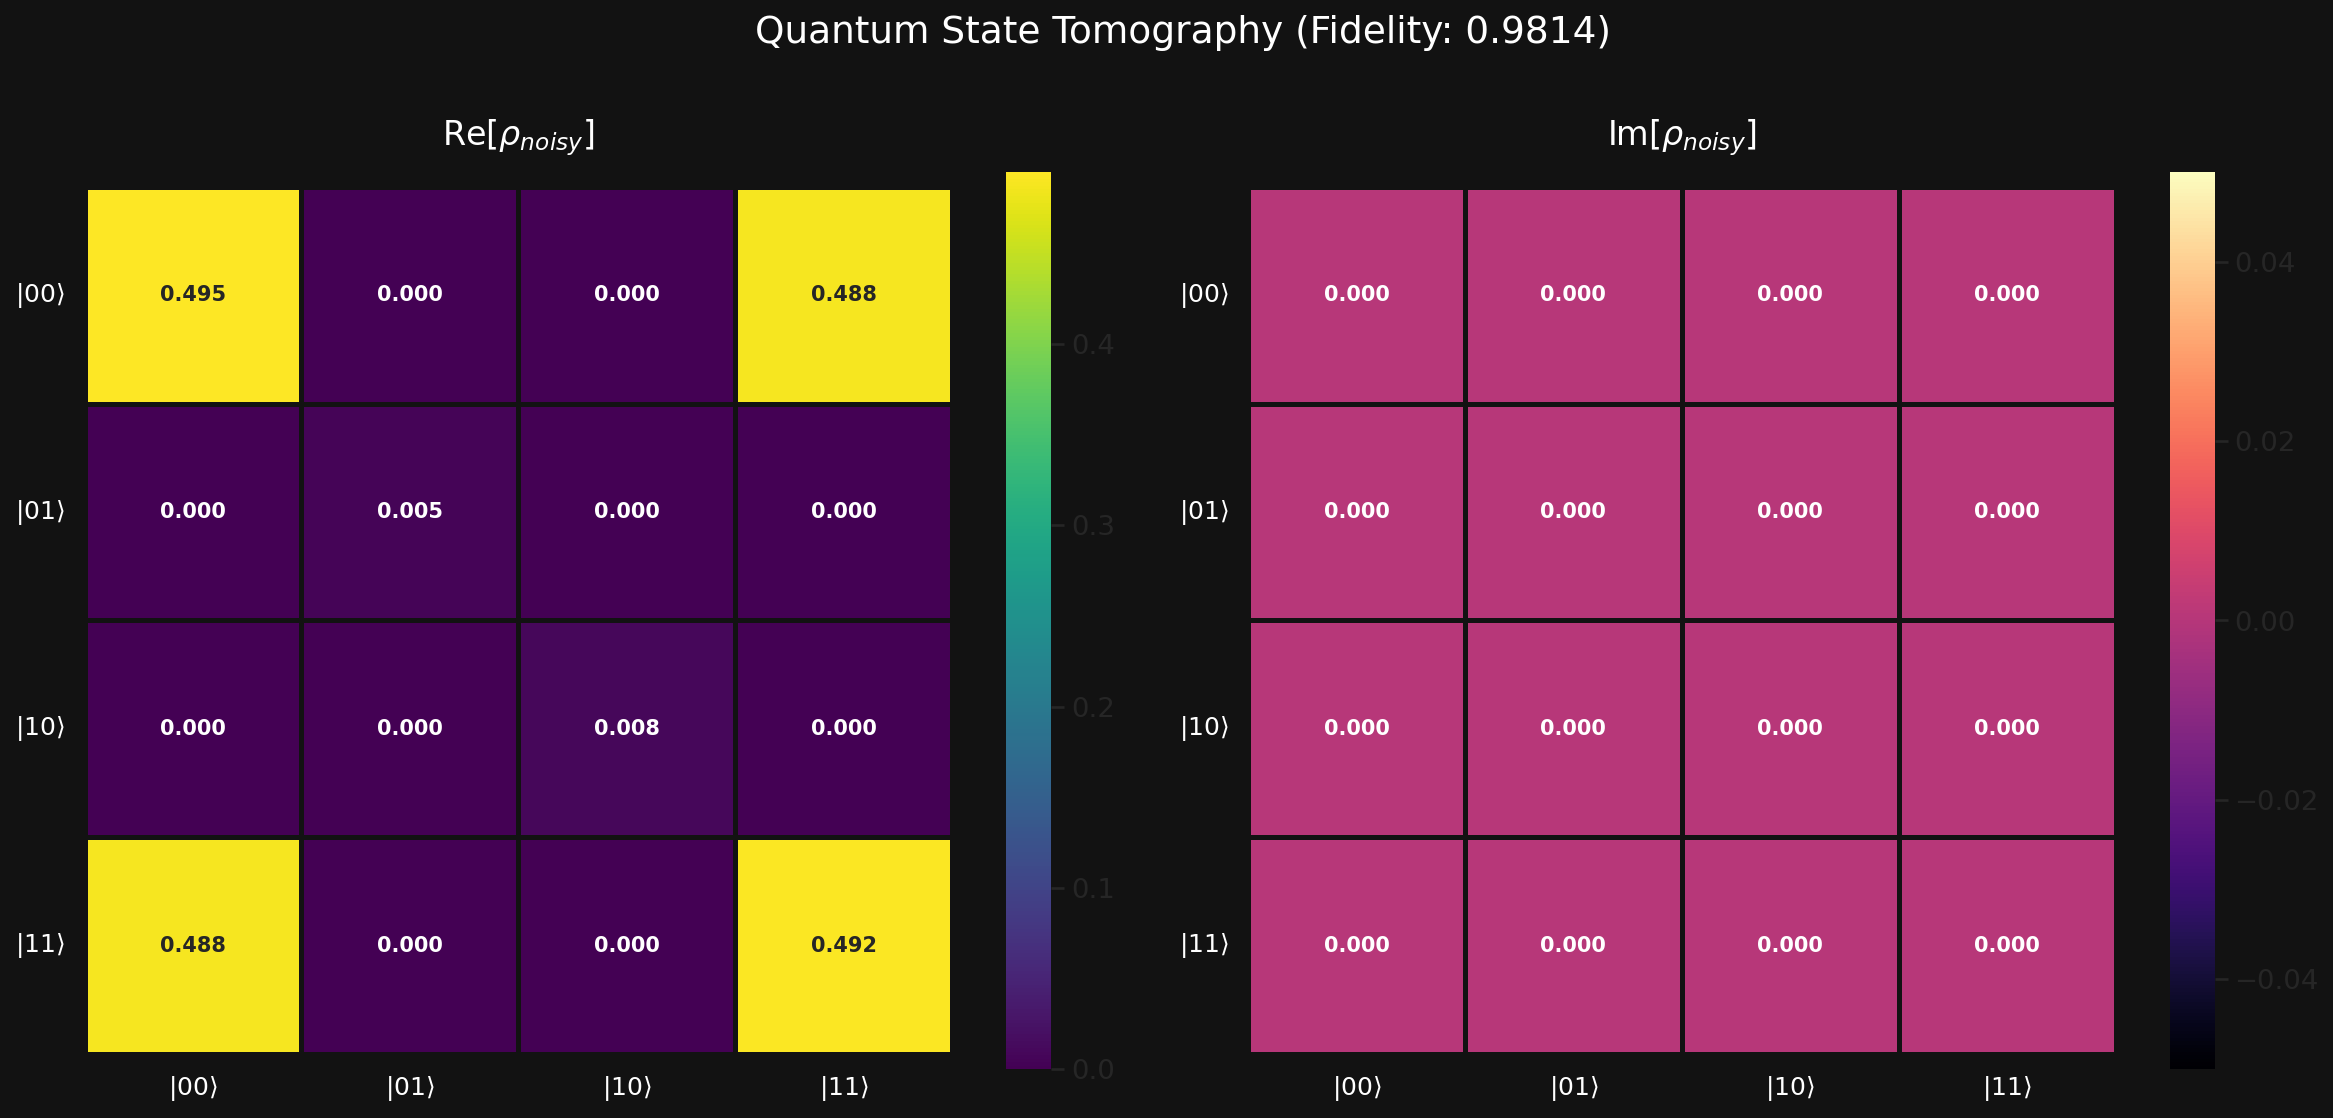

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Common style for heatmaps
heatmap_kwargs = {
    'annot': True,
    'fmt': '.3f',
    'linewidths': 1.5,
    'linecolor': '#121212',
    'square': True,
    'annot_kws': {"size": 10, "weight": "bold"},
    'xticklabels': [r'$|00\rangle$', r'$|01\rangle$', r'$|10\rangle$', r'$|11\rangle$'],
    'yticklabels': [r'$|00\rangle$', r'$|01\rangle$', r'$|10\rangle$', r'$|11\rangle$']
}

# Real Part
sns.heatmap(np.real(noisy_density), ax=axes[0], cmap='viridis', **heatmap_kwargs)
axes[0].set_title(r'Re[$\rho_{noisy}$]', fontsize=16, pad=20, color='white')

# Imaginary Part
sns.heatmap(np.imag(noisy_density), ax=axes[1], cmap='magma', vmin=-0.05, vmax=0.05, **heatmap_kwargs)
axes[1].set_title(r'Im[$\rho_{noisy}$]', fontsize=16, pad=20, color='white')

# Final aesthetic adjustments
for ax in axes:
    ax.tick_params(axis='both', colors='white', labelsize=12)
    plt.setp(ax.get_yticklabels(), rotation=0)

plt.suptitle(f"Quantum State Tomography (Fidelity: {fidelity:.4f})", color='white', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

# Real Quantum Hardware Execution

While noise models provide a robust approximation of hardware behavior, executing the circuit on an actual quantum processor is the ultimate validation of our theoretical derivations.

This section details the workflow for deploying the Bell state circuit to a real superconducting quantum computer via the IBM Quantum platform.

# Transpilation for Physical Hardware

Before execution, a logical quantum circuit must be transpiled to match the physical constraints of the target backend. This involves two critical compilation steps:

* **Basis Gate Decomposition:** Translating high-level logical gates (like $H$ and $CX$) into the hardware's native gate set (e.g., $\{RZ, SX, X, CX\}$ for IBM's superconducting transmon qubits).
* **Qubit Mapping and Routing:** Assigning logical qubits to physical qubits that satisfy the backend's specific connectivity (coupling map). If the required connectivity does not exist, the compiler must insert $SWAP$ gates, which increases circuit depth and, consequently, decoherence.

We utilize Qiskit's `transpile` function with `optimization_level=3` to apply aggressive heuristic optimization, minimizing the final circuit depth and gate count to preserve quantum coherence.

## Hardware Execution Workflow

> **Note:** Executing this cell requires an active IBM Quantum account. If you have not done so, save your API token locally using `IBMProvider.save_account('IBM_QUANTUM_TOKEN')`.

First, we install the necessary provider package:

qiskit_runtime_service._discover_account:WARNING:2026-08-04 16:23:25,471: Loading account with the given token. A saved account will not be used.


Attempting to connect to IBM Quantum...
⚠️ Connection Error: 'No matching instances found for the following filters: .'
🔄 Switching to Local Simulator (Aer) to continue...
✅ Local simulator ready.


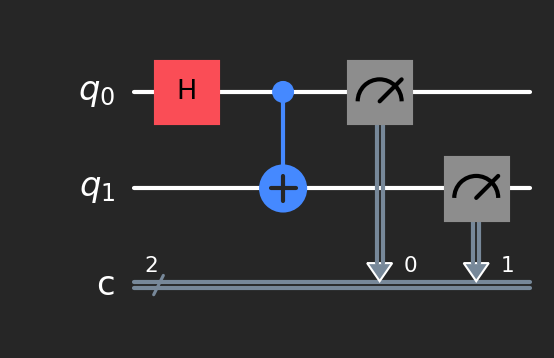

Executing on aer_simulator

Results:
{'11': 4141, '00': 4051}


In [10]:
# 0. Library installation
#!pip install qiskit-ibm-runtime qiskit-aer -q

from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from google.colab import userdata
import matplotlib.pyplot as plt

try:
    # 1. Attempt to connect to IBM Quantum
    TOKEN = userdata.get('IBM_QUANTUM_TOKEN')
    print("Attempting to connect to IBM Quantum...")

    try:
        service = QiskitRuntimeService(channel='ibm_quantum_platform', token=TOKEN)
        # Attempt to get the real backend
        backend = service.least_busy(simulator=False, operational=True)
        print(f"✅ Connected to Real Hardware: {backend.name}")
        sampler = Sampler(mode=backend)
    except Exception as e:
        print(f"⚠️ Connection Error: {e}")
        print("🔄 Switching to Local Simulator (Aer) to continue...")
        backend = AerSimulator()
        sampler = Sampler(mode=backend)
        print("✅ Local simulator ready.")

    # 2. Transpile
    transpiled_circuit = transpile(bell_circuit, backend=backend, optimization_level=3)
    display(transpiled_circuit.draw(output='mpl', style='iqp-dark', fold=-1))

    # 3. Execute
    print(f"Executing on {backend.name if hasattr(backend, 'name') else 'Aer'}")
    job = sampler.run([transpiled_circuit], shots=8192)
    result = job.result()

    # 4. Results
    counts = result[0].data.c.get_counts()
    print("\nResults:")
    print(counts)

except Exception as e:
    print(f"\n❌ Critical Error: {e}")
    print("\nTIP: Verify that 'bell_circuit' is defined in previous cells.")

## Comparative Analysis: Ideal vs. Noisy Simulation vs. Real Hardware

To contextualize the real hardware results, we visualize the measurement distributions from all three environments side-by-side.

This tripartite comparison highlights the fidelity of our noise model and isolates hardware-specific anomalies.

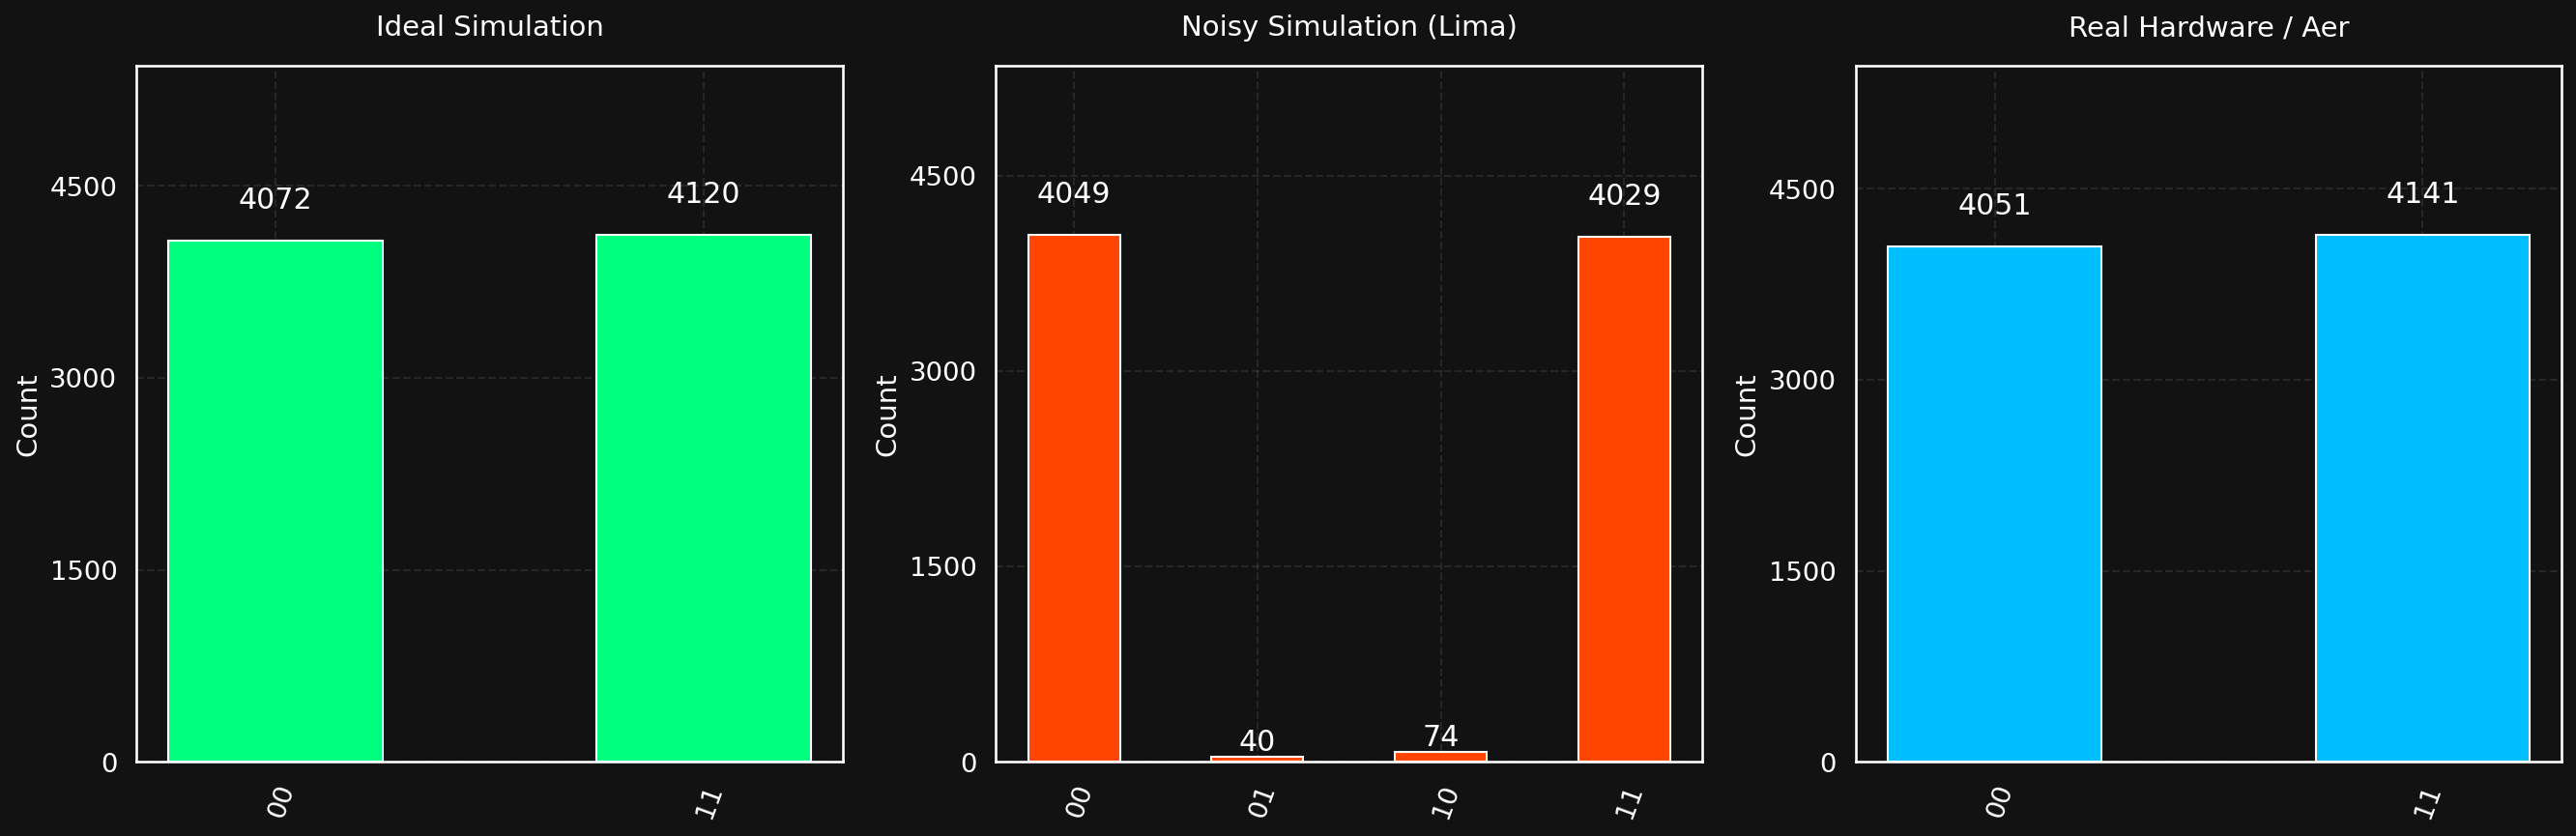

In [11]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Prepare data
data_list = [counts_ideal, counts_noisy, counts]
titles = ['Ideal Simulation', 'Noisy Simulation (Lima)', 'Real Hardware / Aer']
colors = ['#00ff7f', '#ff4500', '#00bfff']

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i in range(3):
    plot_histogram(data_list[i], ax=axes[i], color=colors[i])
    axes[i].set_title(titles[i], color='white', fontsize=14, pad=15)

    # Dark Mode Style
    axes[i].xaxis.label.set_color('white')
    axes[i].yaxis.label.set_color('white')
    axes[i].tick_params(axis='x', colors='white')
    axes[i].tick_params(axis='y', colors='white')

    # Color of text above bars
    for text in axes[i].texts:
        text.set_color('white')

    # Scale adjustment
    curr_ylim = axes[i].get_ylim()
    axes[i].set_ylim(0, curr_ylim[1] * 1.2)
    axes[i].grid(color='gray', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()